In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [3]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
U_disk   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_disk.npy')
dir_disk = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_disk.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']

In [4]:
indices = [27,28,29,30,31,32,33,34,35]

In [5]:
veers = np.array([-0.2,-0.1,-0.05,-0.025,0.0,0.025,0.05,0.1,0.2])

In [6]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction

In [7]:
# LES Baseline

rotor = IEA10MW()

base_les_ind = np.zeros_like(indices, dtype='float')
base_les_cot = np.zeros_like(indices, dtype='float')
base_les_thr = np.zeros_like(indices, dtype='float')
base_les_cop = np.zeros_like(indices, dtype='float')
base_les_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(base_les_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers[count])

    base_les_cot[count] = sol.Ct()
    base_les_thr[count] = sol.thrust()/1e3
    base_les_pow[count] = sol.power()/1e6
    base_les_cop[count] = sol.Cp()
    base_les_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

array([7., 7., 7., 7., 7., 7., 7., 7., 7.])

In [8]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ClassicalMomentum

In [9]:
# 1D Momentum Baseline

rotor = IEA10MW()

base_1D_ind = np.zeros_like(indices, dtype='float')
base_1D_cot = np.zeros_like(indices, dtype='float')
base_1D_thr = np.zeros_like(indices, dtype='float')
base_1D_cop = np.zeros_like(indices, dtype='float')
base_1D_pow = np.zeros_like(indices, dtype='float')
iters       = np.zeros_like(indices, dtype='float')

for count in range(len(base_1D_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ClassicalMomentum(), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    base_1D_cot[count] = sol.Ct()
    base_1D_thr[count] = sol.thrust()/1e3
    base_1D_pow[count] = sol.power()/1e6
    base_1D_cop[count] = sol.Cp()
    base_1D_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

array([4., 4., 4., 4., 4., 4., 4., 4., 4.])

In [10]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, MadsenMomentum

In [11]:
# Madsen Baseline

rotor = IEA10MW()

base_mad_ind = np.zeros_like(indices, dtype='float')
base_mad_cot = np.zeros_like(indices, dtype='float')
base_mad_thr = np.zeros_like(indices, dtype='float')
base_mad_cop = np.zeros_like(indices, dtype='float')
base_mad_pow = np.zeros_like(indices, dtype='float')
iters        = np.zeros_like(indices, dtype='float')

for count in range(len(base_mad_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=MadsenMomentum(averaging='rotor'), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    base_mad_cot[count] = sol.Ct()
    base_mad_thr[count] = sol.thrust()/1e3
    base_mad_pow[count] = sol.power()/1e6
    base_mad_cop[count] = sol.Cp()
    base_mad_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([4., 4., 4., 4., 4., 4., 4., 4., 4.])

In [12]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, GP_Rotor

In [13]:
rotor = IEA10MW()

gpr_ind = np.zeros_like(indices, dtype='float')
gpr_cot = np.zeros_like(indices, dtype='float')
gpr_thr = np.zeros_like(indices, dtype='float')
gpr_cop = np.zeros_like(indices, dtype='float')
gpr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(gpr_ind)):
# for count in [4]:

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=GP_Rotor(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    gpr_cot[count] = sol.Ct()
    gpr_thr[count] = sol.thrust()/1e3
    gpr_pow[count] = sol.power()/1e6
    gpr_cop[count] = sol.Cp()
    gpr_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([9., 9., 9., 9., 9., 9., 9., 9., 9.])

In [14]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, GP_Annulus

In [15]:
rotor = IEA10MW()

gpa_ind = np.zeros_like(indices, dtype='float')
gpa_cot = np.zeros_like(indices, dtype='float')
gpa_thr = np.zeros_like(indices, dtype='float')
gpa_cop = np.zeros_like(indices, dtype='float')
gpa_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

gpa_ind_a = np.zeros((Nelm,len(indices)), dtype='float')
gpa_cot_a = np.zeros((Nelm,len(indices)), dtype='float')

for count in range(len(gpa_ind)):
# for count in [4]:

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=GP_Annulus(veer=veers[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(0, wrf_tsr[index], 0, v_inf = Uhub[index], U = U_loc[:,:,index]/Uhub[index], wdir=dir_loc[:,:,index], veer = veers[count])

    gpa_cot[count] = sol.Ct()
    gpa_thr[count] = sol.thrust()/1e3
    gpa_pow[count] = sol.power()/1e6
    gpa_cop[count] = sol.Cp()
    gpa_ind[count] = sol.a()
    iters[count]   = sol.niter

    gpa_ind_a[:,count] = sol.a('annulus')
    gpa_cot_a[:,count] = sol.Ct('annulus')

iters

array([7., 7., 7., 7., 7., 7., 7., 7., 7.])

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

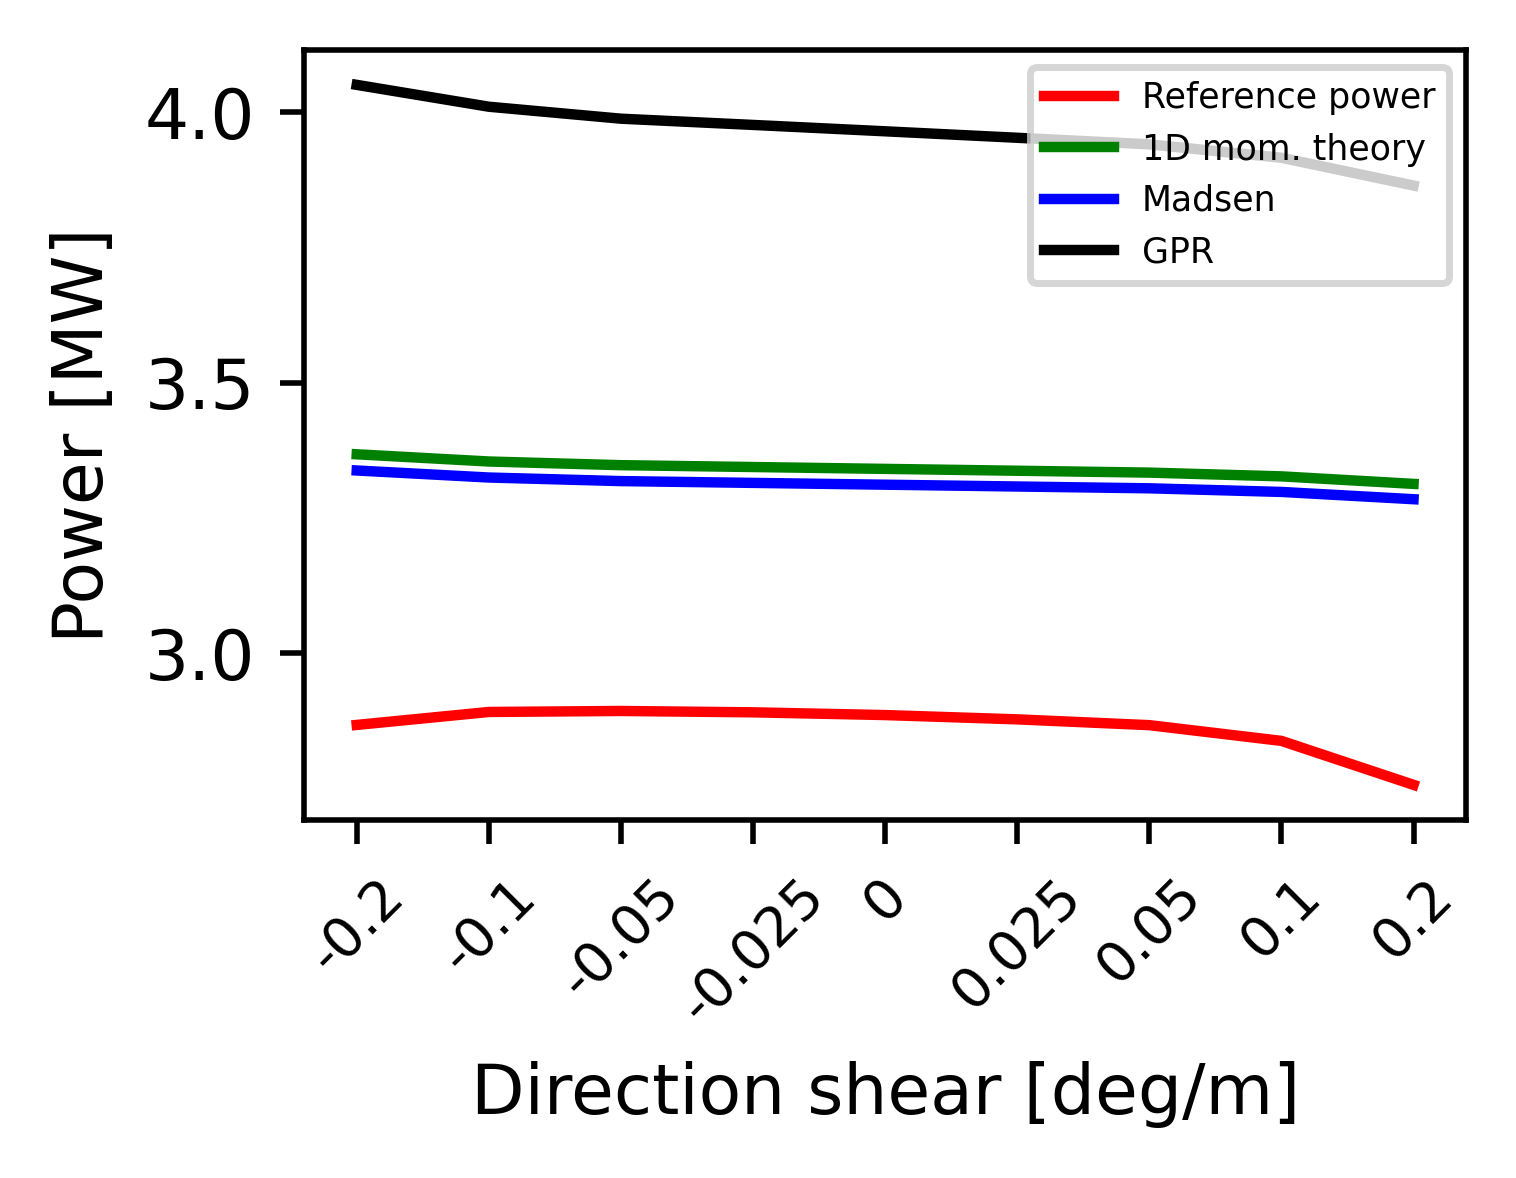

In [16]:
# ROTOR AVERAGE
fig, ax = plt.subplots(figsize=(3, 2))

ax.plot(base_les_pow, color='r', label='Reference power')
ax.plot(base_1D_pow, color='g', label='1D mom. theory')
ax.plot(base_mad_pow, color='b', label='Madsen')
ax.plot(gpr_pow, color='k', label='GPR')
ax.legend(fontsize=5, loc='upper right')

ax.set_ylabel('Power [MW]')
ax.set_xlabel('Direction shear [deg/m]')

# ax.set_yscale('log')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

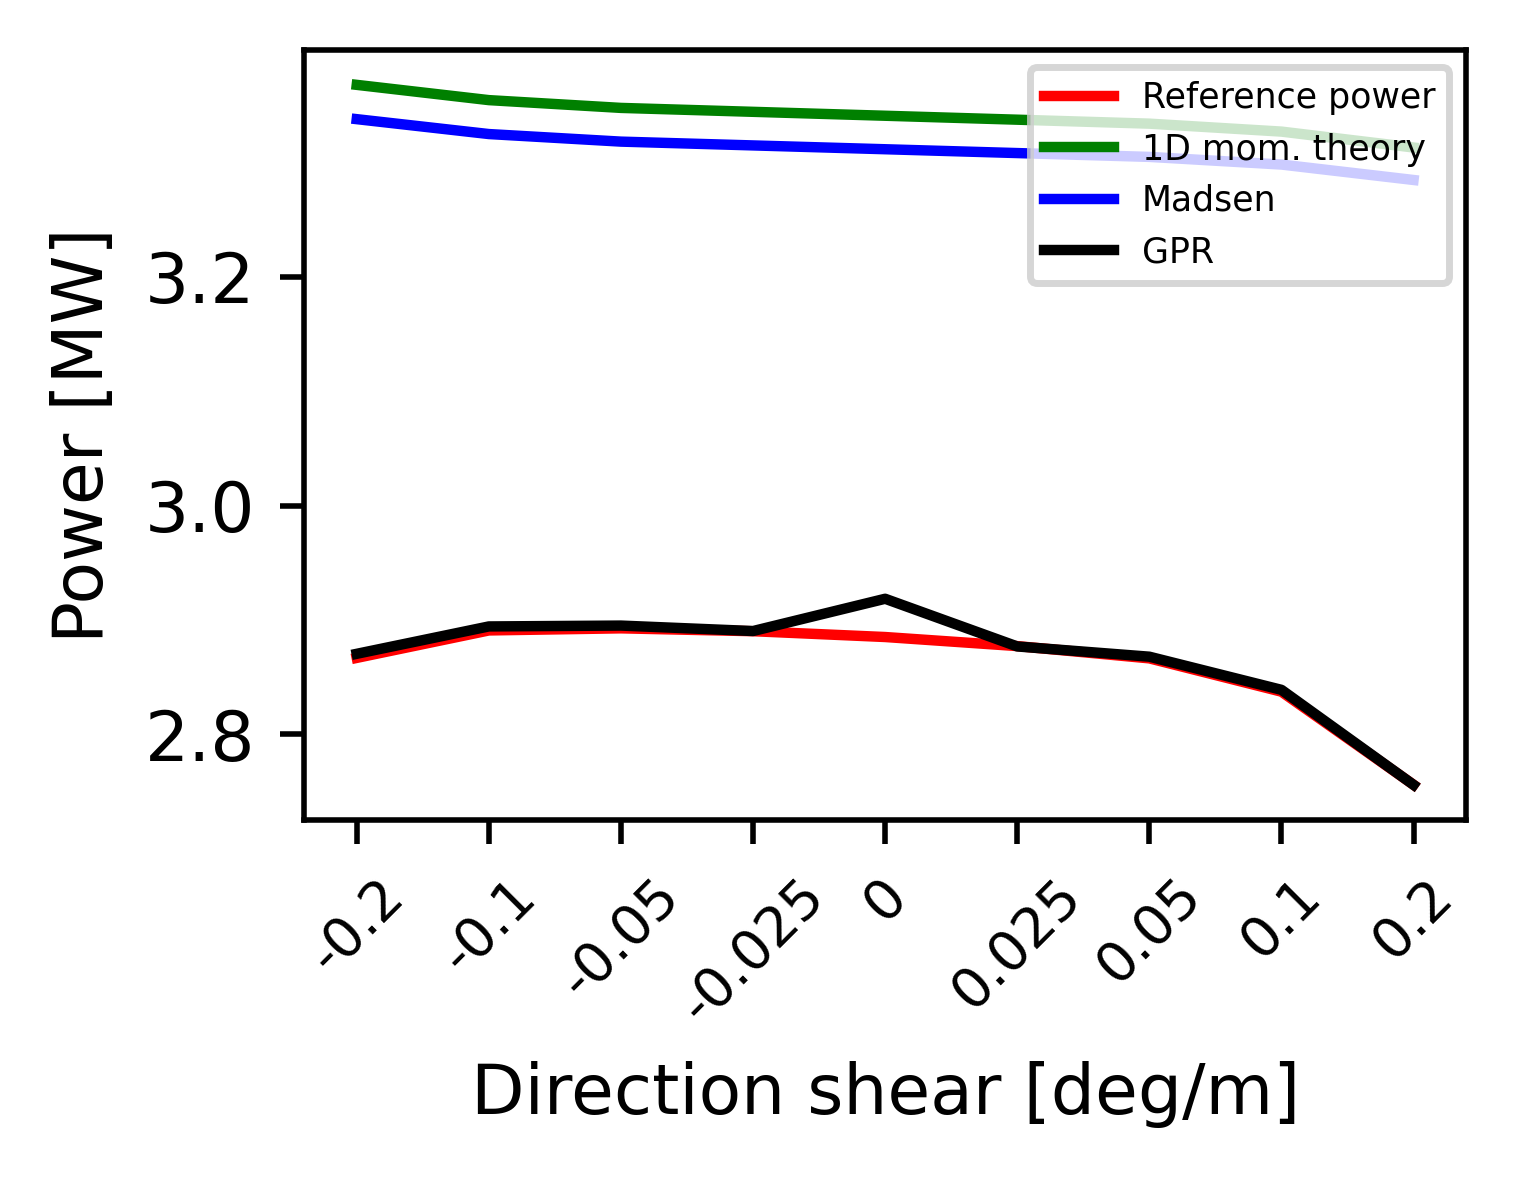

In [17]:
# ANNULUS AVERAGE
fig, ax = plt.subplots(figsize=(3, 2))

ax.plot(base_les_pow, color='r', label='Reference power')
ax.plot(base_1D_pow, color='g', label='1D mom. theory')
ax.plot(base_mad_pow, color='b', label='Madsen')
ax.plot(gpa_pow, color='k', label='GPR')
ax.legend(fontsize=5, loc='upper right')

ax.set_ylabel('Power [MW]')
ax.set_xlabel('Direction shear [deg/m]')

# ax.set_yscale('log')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

[Text(0, 0, '-0.2'),
 Text(1, 0, '-0.1'),
 Text(2, 0, '-0.05'),
 Text(3, 0, '-0.025'),
 Text(4, 0, '0'),
 Text(5, 0, '0.025'),
 Text(6, 0, '0.05'),
 Text(7, 0, '0.1'),
 Text(8, 0, '0.2')]

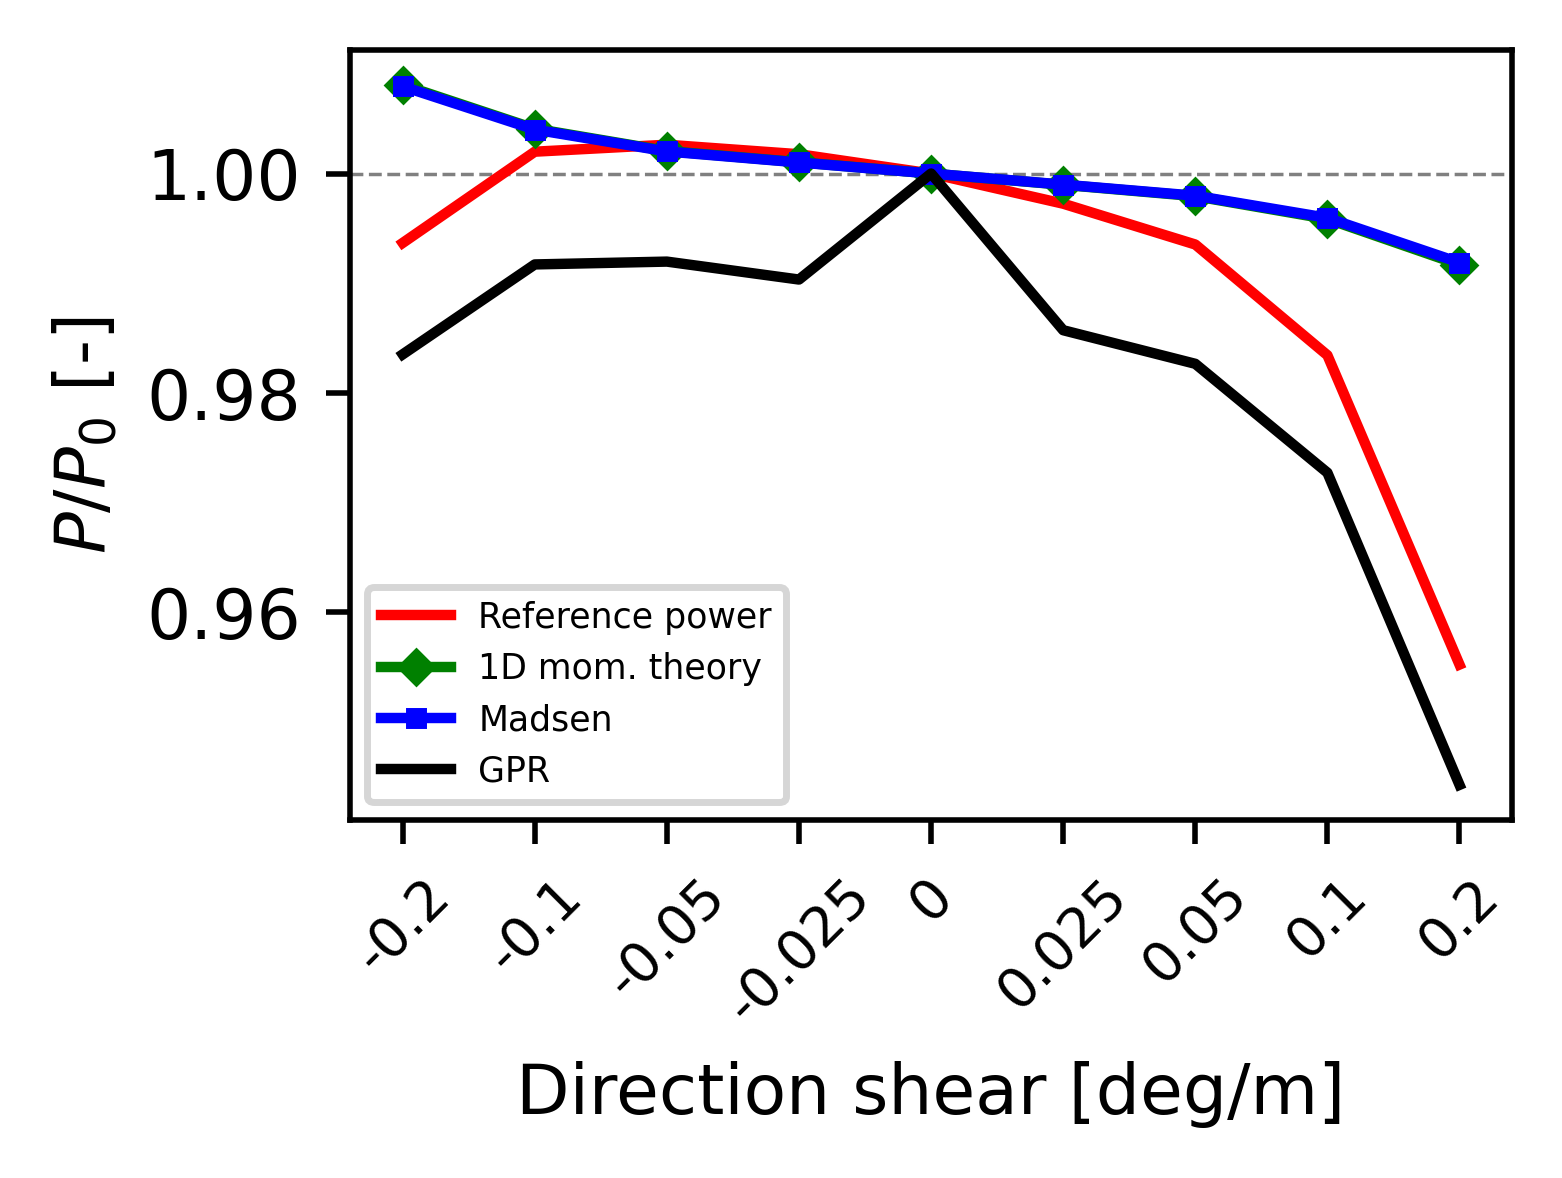

In [18]:
fig, ax = plt.subplots(figsize=(3, 2))

ref_ind = 4

ax.plot(base_les_pow/base_les_pow[ref_ind], color='r', label='Reference power')
ax.plot(base_1D_pow/base_1D_pow[ref_ind], marker='D', markersize=3,color='g', label='1D mom. theory')
ax.plot(base_mad_pow/base_mad_pow[ref_ind], marker = 's', markersize=2, color='b', label='Madsen')
ax.plot(gpa_pow/gpa_pow[ref_ind], color='k', label='GPR')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5,zorder=1)

ax.legend(fontsize=5)

ax.set_ylabel('$P/P_0$ [-]')
ax.set_xlabel('Direction shear [deg/m]')

tick_positions = [0,1,2,3,4,5,6,7,8]  # indices along the x-axis
tick_labels = ['-0.2', '-0.1', '-0.05', '-0.025', '0', '0.025', '0.05', '0.1', '0.2']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=8)

# ax.set_yscale('log')

In [84]:
# Load training data
from scipy.io import loadmat
base_path = '/home1/09909/smata/dir_scratch/induction_modeling/gaussian_process/10MW'
X_train_rot = loadmat(base_path + '/train_data/wrf_10MW_ann.mat')

X_rot = X_train_rot['X']
y_rot = X_train_rot['y'].ravel()

# Load test data
X_test_rot = loadmat(base_path + '/test_data/wrf_10MW_ann.mat')
import pickle

# Replace with the actual file path
with open(base_path + '/train_data/scaler_wrf_cot_ann.pkl', 'rb') as f:
    obj_cot1 = pickle.load(f)

with open(base_path + '/train_data/scaler_shears_ann.pkl', 'rb') as f:
    obj_cot2 = pickle.load(f)

with open(base_path + '/train_data/scaler_veers_ann.pkl', 'rb') as f:
    obj_cot3 = pickle.load(f)

with open(base_path + '/train_data/scaler_wrf_ind_ann.pkl', 'rb') as f:
    obj_ann = pickle.load(f)

X_rot[:,1] = obj_cot1.inverse_transform(X_rot[:,1].reshape(-1, 1)).ravel()
X_rot[:,2] = obj_cot2.inverse_transform(X_rot[:,2].reshape(-1, 1)).ravel()
X_rot[:,3] = obj_cot3.inverse_transform(X_rot[:,3].reshape(-1, 1)).ravel()
y_rot = obj_ann.inverse_transform(y_rot.reshape(-1, 1)).ravel()

X_rot[:,2] = np.round(X_rot[:,2], 2)
X_rot[:,3] = np.round(X_rot[:,3], 2)

# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]
uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) ==0.02 and abs(s) < 0.01)]

In [83]:
X_rot[10,3]

np.float64(-0.1)

ValueError: 'c' argument has 52 elements, which is inconsistent with 'x' and 'y' with size 26.

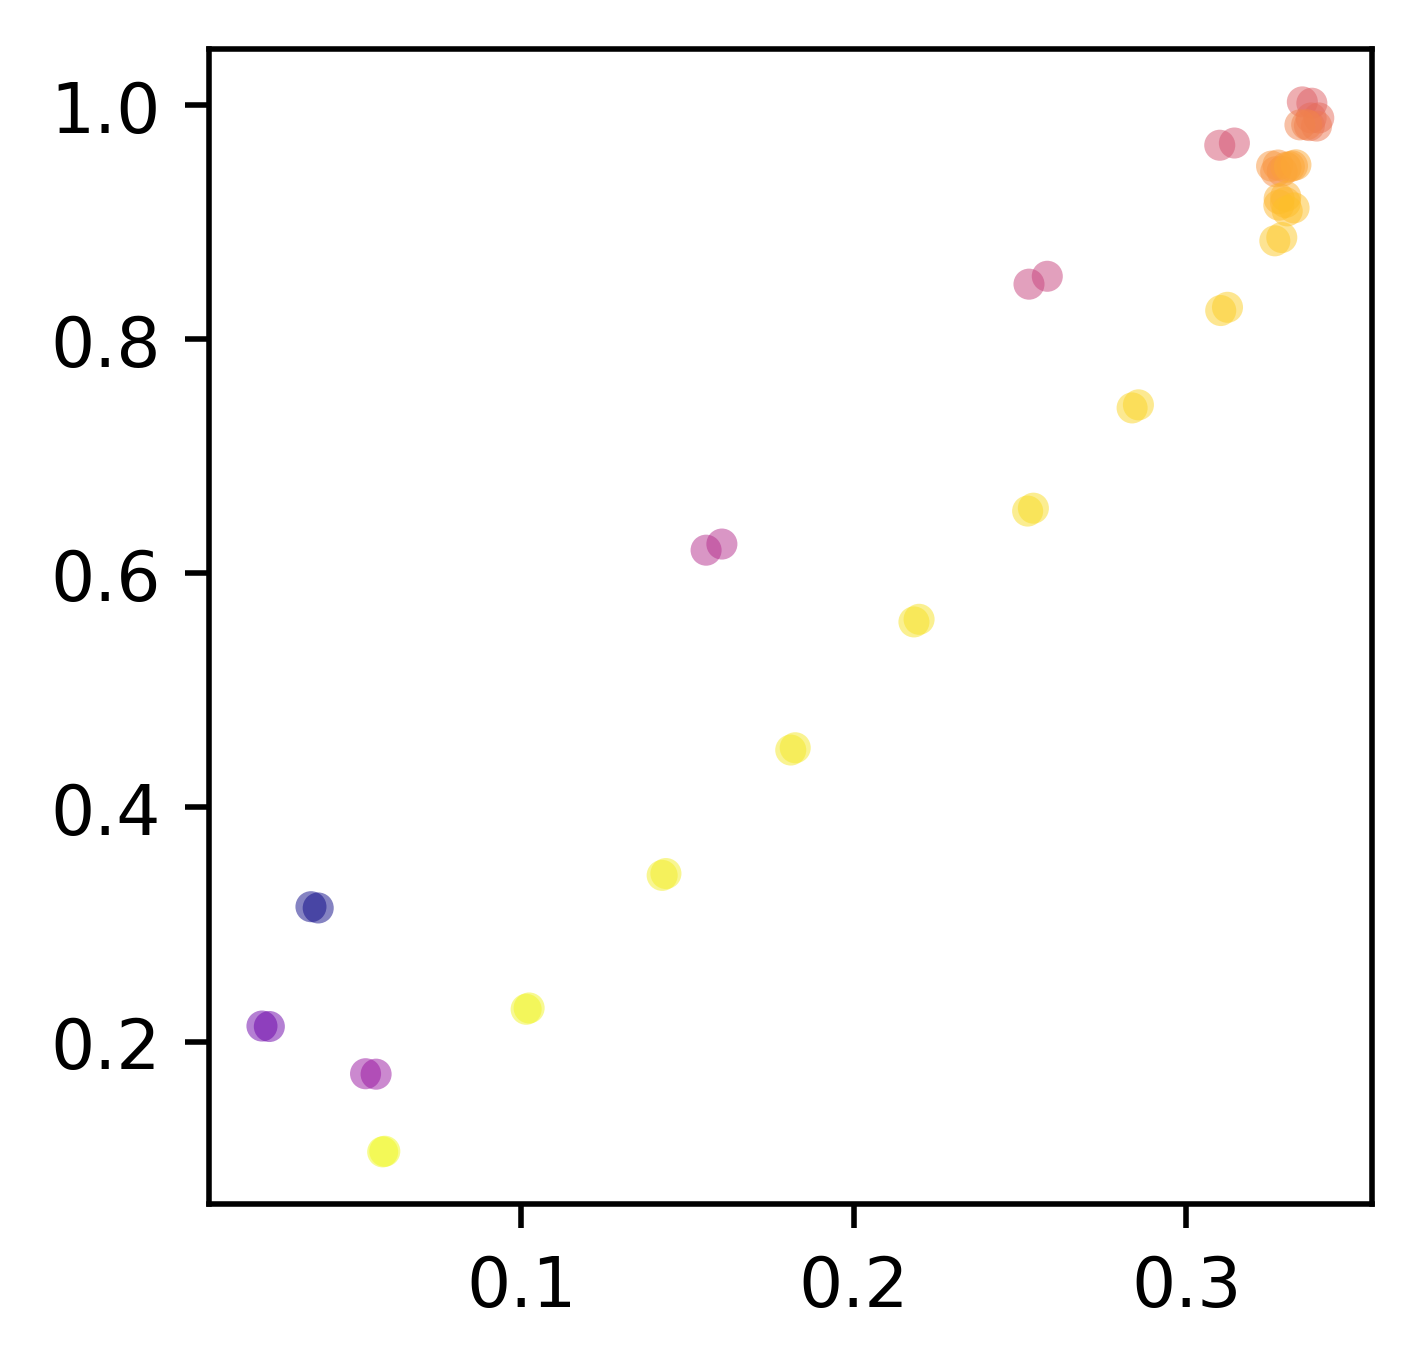

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Select uniform inflow cases (low shear & veer)
# uniform = [i for i, (r, ct, s, v) in enumerate(X_rot) if (abs(v) < 0.01 and abs(s) < 0.01)]

# Extract values
r_vals = X_rot[uniform, 0]
a_vals = y_rot[uniform]
ct_vals = X_rot[uniform, 1]

# Create the scatter plot using actual r_vals for color
fig, ax = plt.subplots(figsize=(3, 3))
# sc = ax.scatter(a_vals, ct_vals, s=10, c=r_vals, cmap='viridis', marker='s', edgecolor='none', alpha=1.0)

import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=r_vals.min(), vmax=r_vals.max())

sc = ax.scatter(a_vals, ct_vals, s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='none', linewidth=0.3, alpha=0.5, label='LES')

sc = ax.scatter(gpa_ind_a[:,4], gpa_cot_a[:,4], s=20, c=r_vals, cmap='plasma',
                norm=norm, marker='o', edgecolor='r', linewidth=0.3, alpha=0.5, label='MITRotor with GPR')

# cbar = plt.colorbar(sc, ax=ax)
cbar = plt.colorbar(sc, ax=ax, ticks=[0.25, 0.5, 0.75])
cbar.set_ticklabels(['0.25', '0.50', '0.75'])  # Optional: format to 2 decimals
cbar.set_label("Radial position $r/R$")

ax.set_ylabel('$C_T$ [-]')
ax.set_xlabel('$a$ [-]')
ax.legend(fontsize=4)
# ax.set_ylim([0.672,0.6952])

# Add colorbar that reflects radial position r
# cbar = plt.colorbar(sc, ax=ax, pad=0.02)
# cbar.set_label('Radial position $r/R$', fontsize=10)
# cbar.ax.tick_params(labelsize=8)



plt.tight_layout()
plt.show()


In [15]:
gpa_ind_a[:,4]

array([0.03350513, 0.017743  , 0.05168679, 0.15106143, 0.24803532,
       0.30521224, 0.33127162, 0.3356898 , 0.3348319 , 0.33190937,
       0.32504914, 0.32342833, 0.32746465, 0.32821496, 0.32500001,
       0.32459769, 0.32681981, 0.32297673, 0.30687071, 0.28042161,
       0.24898461, 0.21468517, 0.17743554, 0.13891642, 0.09717213,
       0.05449711])

In [20]:
a_vals

array([0.22532731, 0.22397194, 0.22688116, 0.23637728, 0.24534948,
       0.25058298, 0.25280289, 0.25302041, 0.25296673, 0.25269848,
       0.25202361, 0.25190765, 0.25230808, 0.25240258, 0.25211938,
       0.25211049, 0.25234612, 0.25200381, 0.2505037 , 0.24804425,
       0.24514461, 0.24198884, 0.23856955, 0.23500001, 0.23122407,
       0.22724073])

In [18]:
gpa_cot_a[:,4]

array([0.31538925, 0.21257422, 0.17260148, 0.64925124, 0.90309094,
       1.01047869, 1.02997812, 1.0089864 , 0.99861504, 0.99765018,
       0.95481412, 0.95935032, 0.95794455, 0.95817238, 0.93001776,
       0.92418846, 0.91898954, 0.89269397, 0.83186014, 0.74729301,
       0.65808026, 0.56240086, 0.45201765, 0.34402914, 0.22896689,
       0.10626214])